In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

path = "/content/drive/MyDrive/JIT_bug_prediction/data/apachejit.csv"

df = pd.read_csv(path)

In [5]:
df['buggy'] = df['buggy'].map({
    False: 0,
    True: 1
})

In [6]:
df['buggy'].value_counts()

,count
buggy,
0,78435
1,28239


In [7]:
features = [
    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

X = df[features]

y = df['buggy']

In [8]:
X = X.fillna(0)

In [9]:
print(X.shape)
print(y.shape)

(106674, 12)
(106674,)


In [10]:
df = df.sort_values(by='author_date')

In [11]:
X = df[features]

y = df['buggy']

In [12]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [13]:
y_train.value_counts()

,count
buggy,
0,60589
1,24750


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

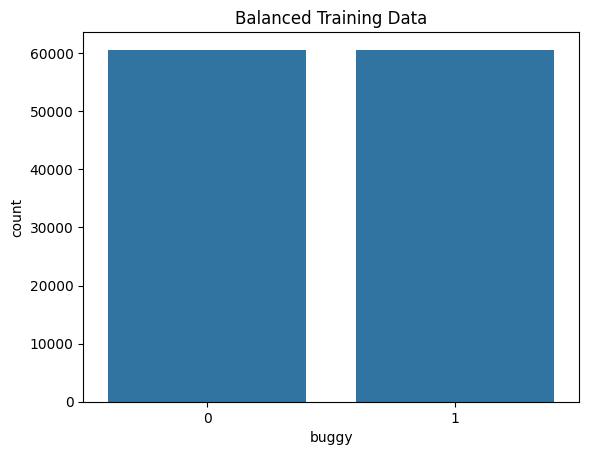

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train_resampled)

plt.title("Balanced Training Data")

plt.show()

In [16]:
processed_path = "/content/drive/MyDrive/JIT_bug_prediction/data/processed_data.csv"

processed_df = pd.concat(
    [X, y],
    axis=1
)

processed_df.to_csv(processed_path, index=False)